# DESI PV Y3 $z$-bin TFR Calibration w/o zero-pointing

Version: **29 June 2026**

**Note:** This requires using a subclassed version of `hyperfit`.

This version removes the per-galaxy volume weighting to see how that changes the fit.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

# We have more than 10 redshift bins, so we need to change the default color map so that they are all plotted with different colors
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('tab20').colors)

import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner, hist2d
import math
import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

In [2]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
H0 = 100*h

q0 = 0.2

# Access SGA Iron Data

The following selections have already been applied:
* `DELTACHI2 > 25` & `ZWARN = 0` for the centers
* $10 < V < 1000$ km/s and $\Delta V / V_\text{min}$ for the observations at $0.4R_{26}$
* Visual inspection

In [3]:
# sgapath = '/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1'
sgapath = '../vrot_cats'
# sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot.fits')
sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot_v3.fits')

sgatab = Table.read(sgafits)
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.97457016,0,0.08361393354574793,2.585694723746872e-05,N,136.40320332954073,12.846761926303119
32,SGA-2020 32,PGC2

In [4]:
### Make sure if we don't have a measurement in one of the bands, we switch the value to NaN
for col in ['G_MAG_SB26', 'R_MAG_SB26','Z_MAG_SB26']:
    sgatab[col][sgatab[col] == -1] = np.nan

## Compute maximum volume for each galaxy

Since the SGA is a size-limited catalog ($D_{26} > 0.2$ arcmin), there is a maximum volume within which each galaxy could be located to be included in the SGA.  Let's calculate that maximum volume so that we can use it as a weight in the TFR calibration.

In [5]:
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)

In [6]:
dist = Distance(z=np.abs(sgatab['Z_DESI']), cosmology=Planck18_h)

sgatab['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*sgatab['D26']*u.arcmin)

sgatab['DIST_MAX'] = 0.5*sgatab['D26_kpc']/np.tan(0.1*u.arcmin)

dist_max = Distance(z=0.1, cosmology=Planck18_h)

sgatab['MAX_VOL_FRAC'] = sgatab['DIST_MAX'].to('Mpc')**3 / dist_max.to('Mpc')**3

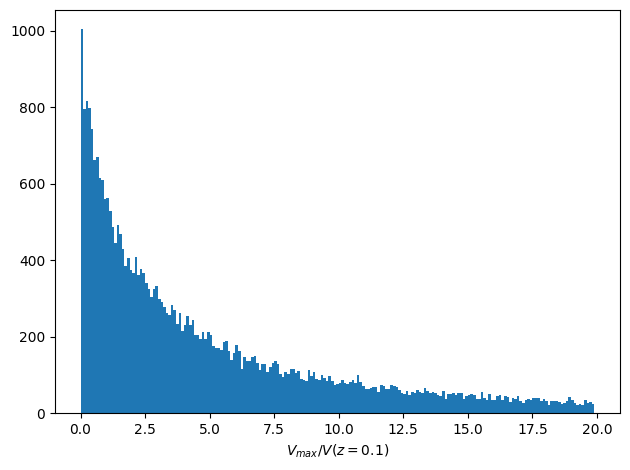

In [7]:
plt.figure(tight_layout=True)

plt.hist(sgatab['MAX_VOL_FRAC'], np.arange(0, 20, 0.1))

plt.xlabel('$V_{max}$/$V(z = 0.1)$');

## Convert to CMB frame

In [8]:
sgatab['Z_DESI_CMB'] = convert_z_frame(sgatab['Z_DESI'], sgatab['RA'], sgatab['DEC'])

# Load Morphological Classification

## SSL

As an alternative to morphological classification of the galaxies, we also produced a classification based on the SSL sorter (using a nearest-neighbor query; Largett et al., in prep.). The classification ignored the Hubble sub-types and grouped the galaxies into four main categories:
1. Spiral
2. Elliptical
3. Lenticular
4. Irregular

Let's also load this table and add it to the SGA table.

In [9]:
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv'
ai_morphpath = '.'
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'
# ai_morphcsv = os.path.join(ai_morphpath, 'sga10278_morphologies_model_analysis.csv')
ai_morphcsv = '/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/SGAY3TFMorphologies.csv'
ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab

SGA_ID,Predicted_Type_spiral,Predicted_Type_elliptical,Predicted_Type_irregular,Predicted_Type_lenticular,Predicted_Type
float64,str6,str10,str9,str10,str10
218203.0,Other,Other,Irregular,Other,Irregular
218205.0,Other,Other,Irregular,Other,Irregular
218239.0,Other,Other,Irregular,Other,Irregular
218275.0,Other,Other,Irregular,Other,Irregular
218304.0,Spiral,Other,Other,Other,Spiral
218367.0,Other,Other,Irregular,Other,Irregular
218376.0,Spiral,Other,Other,Other,Spiral
218201.0,Other,Other,Irregular,Other,Irregular
218385.0,Spiral,Other,Other,Other,Spiral


### Combine ML morphtypes with SGA catalog

In [10]:
sgatab = join(sgatab, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
sgatab['Predicted_Type'].name = 'MORPHTYPE_AI'

## John Lucey's VI results

https://astro.dur.ac.uk/~jrl/DESI_TF_Y1/index.html

We are only considering galaxies that he considers bad for TF (strong asymmetry, double galaxies, stellar contamination).

In [11]:
lucey_VIpath = '../VI_JohnLucey/'

rejects = lucey_VIpath + 'REJECTS.txt'

reject_tab = Table.read(rejects, format='ascii.commented_header')
reject_tab['VI'] = 'reject'
reject_tab

SGA_ID,DESI_NAME,RA,Dec,z_desi,BA,G_R,G_R_err,V_0p4R26,V_0p4R26_err,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,LOGDIST_AVG,LOGDIST_AVG_ERR,MAIN,VI
int64,str22,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,str6
692,DESIXJ12411157+1819512,190.298193,18.330884,0.0691,0.5,0.4903,0.0288,85,6,16.7987,0.1126,0.1983,0.0552,0,reject
2526,DESIXJ10124098+4543539,153.170765,45.731651,0.0241,0.3969,0.3677,0.0227,46,6,16.4224,0.1398,0.1804,0.0717,0,reject
2804,DESIXJ07581109+3420293,119.546191,34.341483,0.0198,0.2924,0.5585,0.035,121,5,14.3538,0.1607,-0.0479,0.0527,0,reject
3420,DESIXJ01135557+0034028,18.48153,0.567434,0.0418,0.761,0.3742,0.0169,82,22,16.5482,0.0542,0.0391,0.1185,0,reject
5964,DESIXJ16261820+4219580,246.57584,42.332773,0.0465,0.9154,0.3389,0.0122,41,23,16.543,0.0311,0.4811,0.2514,0,reject
6243,DESIXJ13403564+1214293,205.148492,12.241463,0.0927,0.6161,0.8506,0.0122,315,14,15.3396,0.0872,-0.1452,0.0505,0,reject
6493,DESIXJ12450567+1054032,191.273606,10.900881,0.0035,0.8997,0.6761,0.0011,213,23,13.575,0.0287,-0.8711,0.0609,0,reject
7553,DESIXJ09534429-0005255,148.434553,-0.090407,0.0836,0.7665,0.6715,0.0185,237,20,15.136,0.0574,0.0103,0.0557,0,reject
8007,DESIXJ03051303-0700487,46.304307,-7.013516,0.0284,0.427,0.4408,0.0256,25,10,16.5644,0.1281,0.5769,0.1991,0,reject


### Combine John's results with Y1 TF sample

In [12]:
sgatab = join(sgatab, reject_tab['SGA_ID', 'VI'], keys='SGA_ID', join_type='left')

# Rename VI column to JOHN_VI
sgatab['VI'].name = 'JOHN_VI'

In [13]:
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,D26_kpc,DIST_MAX,MAX_VOL_FRAC,Z_DESI_CMB,MORPHTYPE_AI,JOHN_VI
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,,,,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,str10,str6
20.0,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.641

# Photometric corrections

### Survey offsets

In [14]:
sys_corr, sys_corr_err = BASS_corr(sgatab['PHOTSYS'])

### MW dust corrections

In [15]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [16]:
MWdust_corr, MWdust_corr_err = MW_dust(sgatab['RA'], sgatab['DEC'], ebv_map)

/global/u1/s/sgmoore1/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [17]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

### $K$-corrections

In [18]:
# # Apparently we have some galaxies with negative redshifts
# zg0 = sgatab['Z_DESI'] >= 0

In [19]:
# kcorr_zg0 = k_corr(sgatab['Z_DESI'][zg0], 
#                    [sgatab['G_MAG_SB26'][zg0], sgatab['R_MAG_SB26'][zg0], sgatab['Z_MAG_SB26'][zg0]], 
#                    [sgatab['G_MAG_SB26_ERR'][zg0], sgatab['R_MAG_SB26_ERR'][zg0], sgatab['Z_MAG_SB26_ERR'][zg0]], 
#                    z_corr=0.1) # K-correcting to same redshift as FastSpecFit (which is what Caitlin's using for the FP)

In [20]:
# kcorr = np.zeros([len(sgatab), 3])
# kcorr[zg0] = kcorr_zg0

### Internal dust extinction correction

This is based off of a linear fit to ($b/a$, $m_r$), removing any correlation between $b/a$ and $m_r$.

In [21]:
# temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'rb')
temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'rb')
# temp_infile = open('../loa_internalDust_nokcorr_mcmc.pickle', 'rb') #without k-corr
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [22]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [23]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

## Apply corrections

In [24]:
# sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - kcorr[:,0] - internalDust_corr_g
# sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - kcorr[:,1] - internalDust_corr_r
# sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - kcorr[:,2] - internalDust_corr_z

In [25]:
##### without k-correction

sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - internalDust_corr_g
sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - internalDust_corr_r
sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - internalDust_corr_z

In [26]:
# #### no corrections
# sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26']
# sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26']
# sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26']

# sgatab['G_MAG_SB26_ERR_CORR'] = sgatab['G_MAG_SB26_ERR']
# sgatab['R_MAG_SB26_ERR_CORR'] = sgatab['R_MAG_SB26_ERR']
# sgatab['Z_MAG_SB26_ERR_CORR'] = sgatab['Z_MAG_SB26_ERR']

In [27]:
sgatab['G_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + sys_corr_err**2 + internalDust_corr_err_g**2)
sgatab['R_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + sys_corr_err**2 + internalDust_corr_err_r**2)
sgatab['Z_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + sys_corr_err**2 + internalDust_corr_err_z**2)

In [28]:
#### Add extra columns for Alex 

sgatab['R_MWDUST_CORR'] = MWdust_corr[1]
sgatab['R_SYS_CORR'] = sys_corr
sgatab['R_INTDUST_CORR'] = internalDust_corr_r

sgatab['MU_ZCMB'] = Planck18_h.distmod(sgatab['Z_DESI_CMB'])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['G_ABSMAG_SB26'] = sgatab['G_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['Z_ABSMAG_SB26'] = sgatab['Z_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

sgatab['logV'] = np.log10(sgatab['V_0p4R26'])
sgatab['logV_ERR'] = 0.434*sgatab['V_0p4R26_ERR']/sgatab['V_0p4R26']

sgatab['R_ABSMAG_SB26_CORR'] = sgatab['R_ABSMAG_SB26']
sgatab['R_ABSMAG_SB26_ERR'] = sgatab['R_MAG_SB26_ERR_CORR']
sgatab['R_ABSMAG_SB26_ERR_CORR'] = sgatab['R_MAG_SB26_ERR_CORR']

sgatab['G_ABSMAG_SB26_CORR'] = sgatab['G_ABSMAG_SB26']
sgatab['G_ABSMAG_SB26_ERR'] = sgatab['G_MAG_SB26_ERR_CORR']
sgatab['G_ABSMAG_SB26_ERR_CORR'] = sgatab['G_MAG_SB26_ERR_CORR']

sgatab['Z_ABSMAG_SB26_CORR'] = sgatab['Z_ABSMAG_SB26']
sgatab['Z_ABSMAG_SB26_ERR'] = sgatab['Z_MAG_SB26_ERR_CORR']
sgatab['Z_ABSMAG_SB26_ERR_CORR'] = sgatab['Z_MAG_SB26_ERR_CORR']


# sgatab.write('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/SGA-2020_loa_Vrot_VI_v0.fits', overwrite=True)

# Make a morphology cut to only include spirals

In [29]:
sgatab = sgatab[sgatab['MORPHTYPE_AI']=='Spiral']

# Redshift bins

Separate the galaxies into redshift bins of width 0.005, starting at a redshift of 0, so that we can fit an ellipse in each redshift bin.

In [30]:
zmin=0
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [31]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.000    0 galaxies
 1  0.000 < z <= 0.005   35 galaxies
 2  0.005 < z <= 0.010  138 galaxies
 3  0.010 < z <= 0.015  317 galaxies
 4  0.015 < z <= 0.020  596 galaxies
 5  0.020 < z <= 0.025  970 galaxies
 6  0.025 < z <= 0.030  1450 galaxies
 7  0.030 < z <= 0.035  1839 galaxies
 8  0.035 < z <= 0.040  1679 galaxies
 9  0.040 < z <= 0.045  1680 galaxies
10  0.045 < z <= 0.050  1478 galaxies
11  0.050 < z <= 0.055  1497 galaxies
12  0.055 < z <= 0.060  1430 galaxies
13  0.060 < z <= 0.065  1499 galaxies
14  0.065 < z <= 0.070  1427 galaxies
15  0.070 < z <= 0.075  1221 galaxies
16  0.075 < z <= 0.080  1183 galaxies
17  0.080 < z <= 0.085  1138 galaxies
18  0.085 < z <= 0.090  865 galaxies
19  0.090 < z <= 0.095  615 galaxies
20  0.095 < z <= 0.100  480 galaxies
21  z > 0.100  2458 galaxies


# Apply Cuts Suitable for Calibrating the TFR

Requirements:
* $10~\mathrm{km/s} < V_\mathrm{rot} < 1000~\mathrm{km/s}$ at $0.4R_{26}$
* $\Delta V/V_\mathrm{min} \leq 5$
* Passed visual inspection (both ours and John Lucey's)
* $i > 45^\circ$
* Spiral-type morphology
* Not an outlier (based on fitting an ellipse to the data)

The first 2.5 items have already been applied (our VI results have already been applied, but not John's).

In [32]:
def fit_ellipse(x,y, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)
    return ee.location_, ee.covariance_

def plot_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Draw a confidence ellipse from mean and covariance.
    n_std=2 ~ 95% for 2D
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))

    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)

def ellipse_boolean(x,y,n_std, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)

    mahal_sq = ee.mahalanobis(X)
    outlier_boolean = mahal_sq > n_std**2
    return outlier_boolean

## Fit an ellipse in each redshift bin

In [33]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [34]:
zmin=0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [35]:
# sigma = 2.5
sigma = 2.86
mu_x = []
mu_y = []
cov_xx = []
cov_xy = []
cov_yx = []
cov_yy = []
z_min = []
# # fit the lowest bin in absolute magnitude space (if we don't want to start at zero)
# z_min.append(0)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 


for i in range(1,len(zbins)):
    z_min.append(0.005*(i-1))
    x = np.log10(sgatab['V_0p4R26'][zbin_indices==i])
    y = sgatab['R_MAG_SB26_CORR'][zbin_indices==i]

    ellipse_mean, ellipse_cov = fit_ellipse(x,y, contam=0.05)
    # print(ellipse_mean, ellipse_cov)
    mu_x.append(ellipse_mean[0])
    mu_y.append(ellipse_mean[1])
    cov_xx.append(ellipse_cov[0][0]) 
    cov_xy.append(ellipse_cov[0][1]) 
    cov_yx.append(ellipse_cov[1][0]) 
    cov_yy.append(ellipse_cov[1][1]) 

# # ## fit the highest bin in absolute magnitude space (if we care about above z=0.1)
# i=len(zbins)
# z_min.append(zmax)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

In [36]:
ellipse_params = Table([mu_x, mu_y, cov_xx, cov_xy, cov_yx, cov_yy],
    names=['MU_X', 'MU_Y', 'COV_XX', 'COV_XY', 'COV_YX', 'COV_YY'])
# ellipse_params.write(f'/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/v3/TF_Y3_ellipse_fit_mr_0p01-0p1.fits')

In [37]:
ellipse_params

MU_X,MU_Y,COV_XX,COV_XY,COV_YX,COV_YY
float64,float64,float64,float64,float64,float64
1.8645797305317762,14.981432454428887,0.03530137957323242,-0.17778461832113573,-0.17778461832113573,1.213077047439212
1.9574796582987877,15.036643959991567,0.032733599206188825,-0.1686408540587039,-0.1686408540587039,1.150193263443568
1.9988484415529912,15.216289322563567,0.027757900188068504,-0.13590479865513028,-0.13590479865513028,0.922139928545052
2.039196247839816,15.340836982778905,0.02355924757158254,-0.11534453575438398,-0.11534453575438398,0.7863423095763967
2.0691104223111054,15.461590200130338,0.020641444110356073,-0.10081598049865428,-0.10081598049865428,0.6669162525917395
2.097494865818216,15.553576648636867,0.017953321167566736,-0.07894671856663822,-0.07894671856663822,0.5152693920667463
2.123647484959642,15.611193568687137,0.016303190059218806,-0.06905564872513249,-0.06905564872513249,0.45000075536699663
2.1326664415283862,15.760311423222364,0.016618143918884252,-0.07047170933678693,-0.07047170933678693,0.4322984684919371
2.159390739843744,15.803863256020387,0.013916859317528686,-0.05881936927236592,-0.05881936927236592,0.37790710170299635


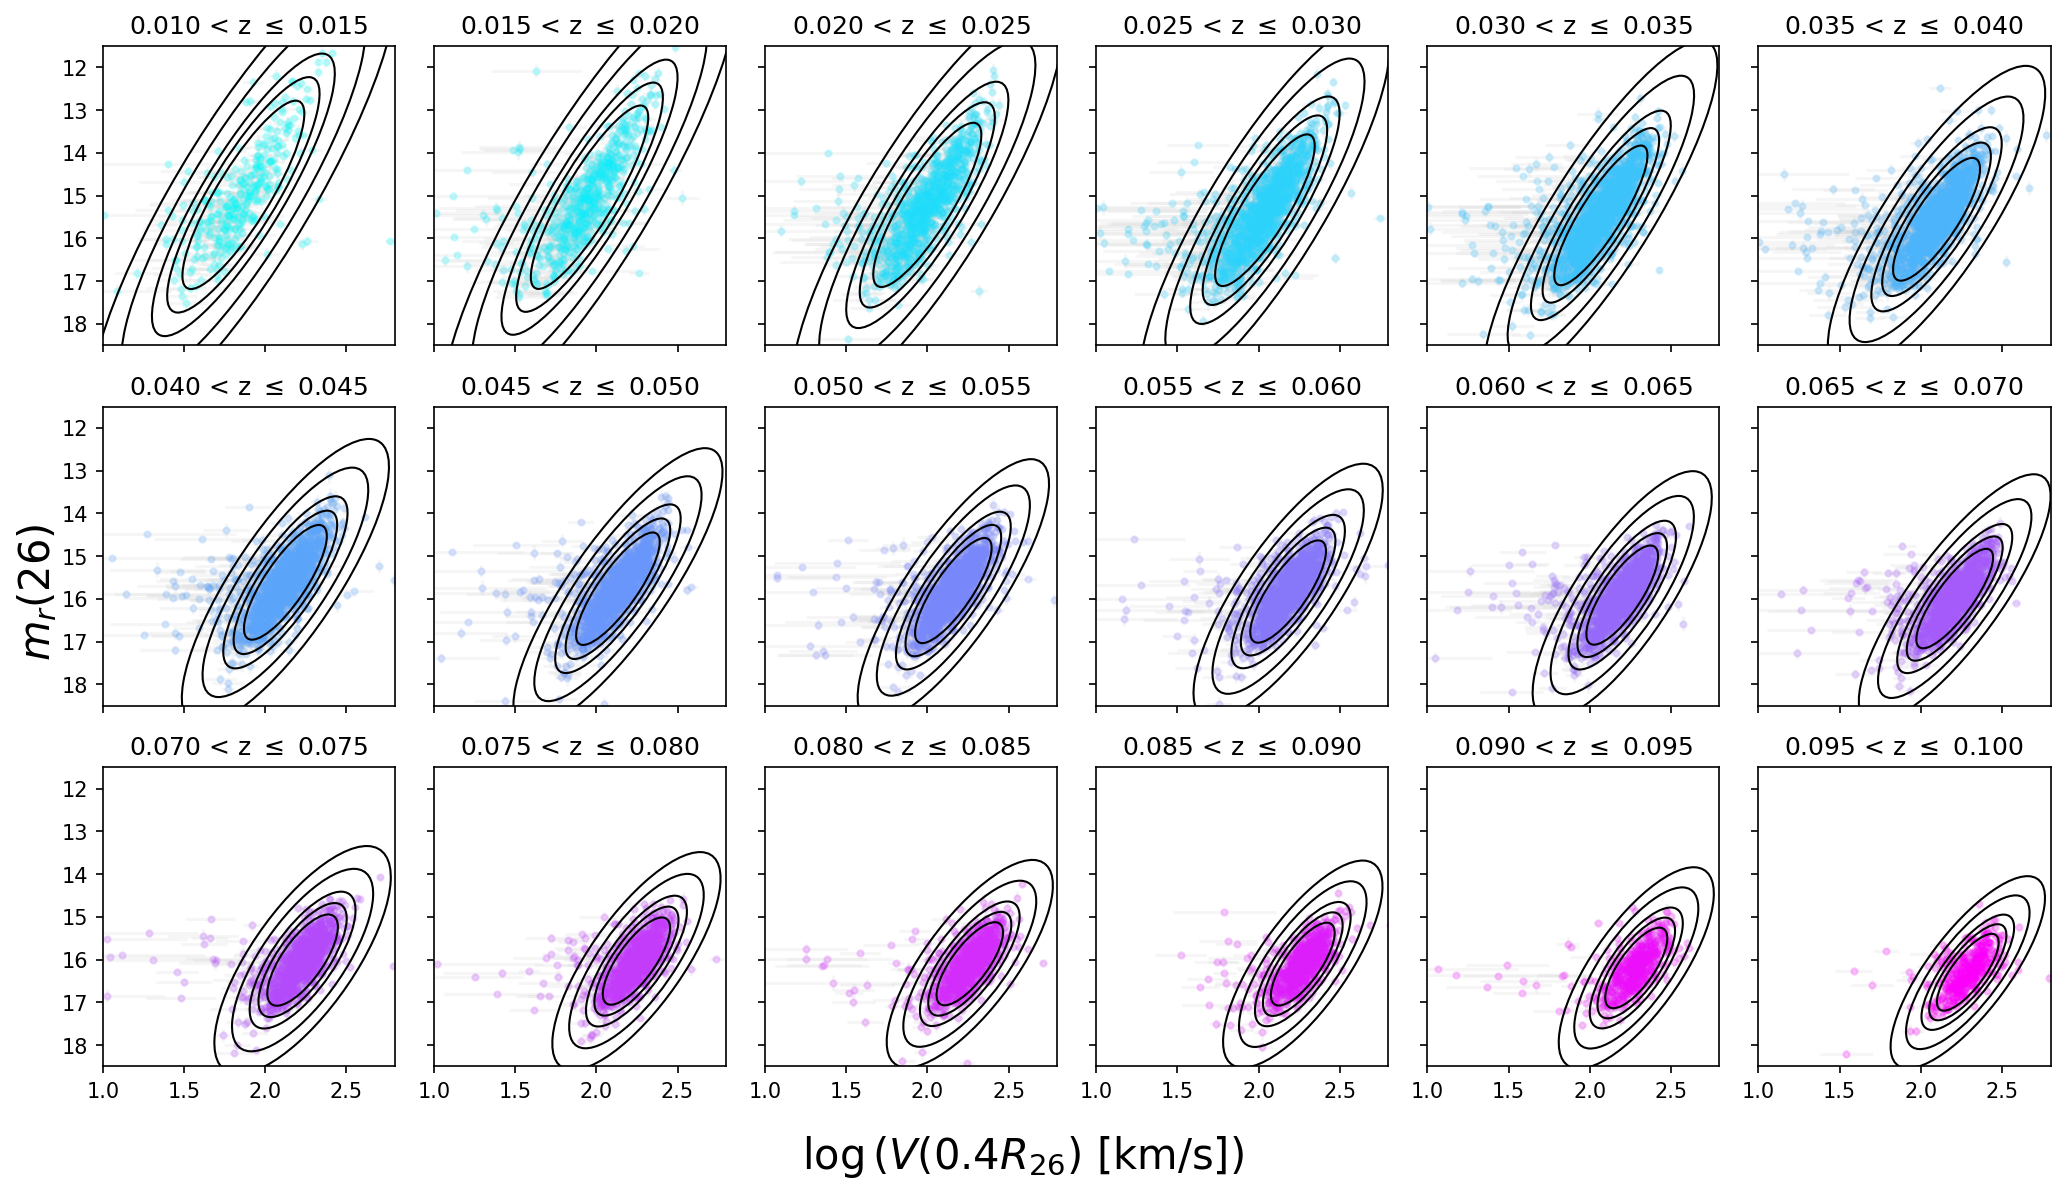

In [38]:
ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2.5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 3, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 4, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_prefit.png', 
#             dpi=150, 
#             facecolor='none')


In [39]:
# sigma=2.5

zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

outlier_boolean = np.zeros(len(sgatab), dtype=bool)

# ## do the lowest and highest bins separately since they are in absmag space
bin_mask = (zbin_indices == 0)
x = np.log10(sgatab['V_0p4R26'][bin_mask])
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

for i in range(1,len(zbins)):
    bin_mask = (zbin_indices == i)

    x = np.log10(sgatab['V_0p4R26'][bin_mask])
    y = sgatab['R_MAG_SB26_CORR'][bin_mask]

    # Outliers *within this bin*
    outlier_bin = ellipse_boolean(x, y, sigma)

    # Write results back into global array
    outlier_boolean[bin_mask] = outlier_bin

bin_mask = (zbin_indices == len(zbins))
x = np.log10(sgatab['V_0p4R26'][bin_mask])
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

print(np.sum(outlier_boolean), len(outlier_boolean), np.sum(outlier_boolean)/len(outlier_boolean))

1953 23995 0.081391956657637


In [40]:
zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'][~outlier_boolean], zbins, right=True)

binwidth=dz

for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010  153 galaxies
 1  0.010 < z <= 0.015  285 galaxies
 2  0.015 < z <= 0.020  539 galaxies
 3  0.020 < z <= 0.025  895 galaxies
 4  0.025 < z <= 0.030  1324 galaxies
 5  0.030 < z <= 0.035  1656 galaxies
 6  0.035 < z <= 0.040  1513 galaxies
 7  0.040 < z <= 0.045  1551 galaxies
 8  0.045 < z <= 0.050  1360 galaxies
 9  0.050 < z <= 0.055  1377 galaxies
10  0.055 < z <= 0.060  1315 galaxies
11  0.060 < z <= 0.065  1373 galaxies
12  0.065 < z <= 0.070  1318 galaxies
13  0.070 < z <= 0.075  1142 galaxies
14  0.075 < z <= 0.080  1096 galaxies
15  0.080 < z <= 0.085  1059 galaxies
16  0.085 < z <= 0.090  800 galaxies
17  0.090 < z <= 0.095  569 galaxies
18  0.095 < z <= 0.100  431 galaxies
19  z > 0.100  2286 galaxies


## Apply other cuts

In [41]:
#- Inclination cut
cosi2 = (sgatab['BA']**2 - q0**2) / (1 - q0**2)
i_min = 45. * u.degree
cosi2_max = np.cos(i_min)**2
is_good_incl = cosi2 < cosi2_max

#- Morphology cut: only ML
is_good_morph_ML = np.zeros_like(is_good_incl, dtype=bool)
for i in range(len(sgatab)):
    if sgatab['MORPHTYPE_AI'][i] == 'Spiral':
        is_good_morph_ML[i] = True

#- John's VI
is_good_John = sgatab['JOHN_VI'].mask

#- Combine selections:
is_good_sga = is_good_incl & is_good_morph_ML & is_good_John & ~outlier_boolean

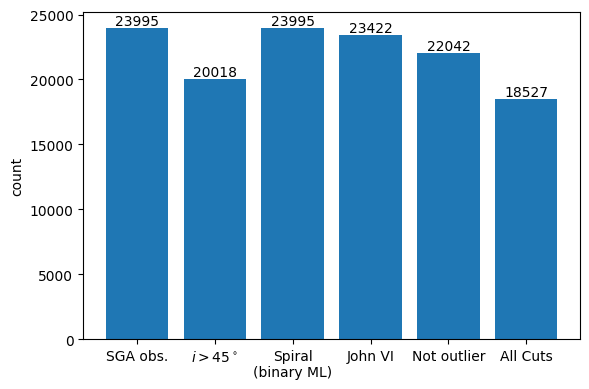

In [42]:
data = {
    'SGA obs.' : len(sgatab),
    # r'$10 < V_\mathrm{rot} < 1000$' : np.sum(is_good_velo),
    # r'$\Delta V/V_\mathrm{min}>5$' : np.sum(is_good_dv),
    r'$i > 45^\circ$' : np.sum(is_good_incl), 
    # 'Spiral' : np.sum(is_good_morph),
    'Spiral\n(binary ML)' : np.sum(is_good_morph_ML),
    'John VI' : np.sum(is_good_John), 
    # 'Not dwarf' : np.sum(~dwarf_boolean), 
    'Not outlier' : np.sum(~outlier_boolean), 
    'All Cuts' : np.sum(is_good_sga), 
    # 'All Cuts\n(binary ML)' : np.sum(is_good_sga_ML)
}
names = list(data.keys())
values = list(data.values())

fig, ax = plt.subplots(1, 1, figsize=(6,4), tight_layout=True)
bars = ax.bar(names, values, color='tab:blue')
ax.bar_label(bars, fmt='%d')
ax.set(ylabel='count');#, yscale='log', ylim=[1e3,1.2e4]);

# fig.savefig('../../Figures/Y1/TF_Y1_SGA_Vrot_cuts.png', dpi=150, facecolor='none');

In [43]:
sgatab_sel = sgatab[is_good_sga]
zbin_indices = np.digitize(sgatab_sel['Z_DESI_CMB'], zbins, right=True)

In [44]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010   92 galaxies
 1  0.010 < z <= 0.015  234 galaxies
 2  0.015 < z <= 0.020  446 galaxies
 3  0.020 < z <= 0.025  741 galaxies
 4  0.025 < z <= 0.030  1092 galaxies
 5  0.030 < z <= 0.035  1378 galaxies
 6  0.035 < z <= 0.040  1247 galaxies
 7  0.040 < z <= 0.045  1238 galaxies
 8  0.045 < z <= 0.050  1116 galaxies
 9  0.050 < z <= 0.055  1153 galaxies
10  0.055 < z <= 0.060  1098 galaxies
11  0.060 < z <= 0.065  1148 galaxies
12  0.065 < z <= 0.070  1111 galaxies
13  0.070 < z <= 0.075  973 galaxies
14  0.075 < z <= 0.080  919 galaxies
15  0.080 < z <= 0.085  922 galaxies
16  0.085 < z <= 0.090  690 galaxies
17  0.090 < z <= 0.095  502 galaxies
18  0.095 < z <= 0.100  375 galaxies
19  z > 0.100  2052 galaxies


In [45]:
_, counts = np.unique(zbin_indices, return_counts=True)

print(np.min(counts[1:-1]), np.max(counts[1:-1]))

234 1378


# Build the Calibration Table of SGA Galaxies

In [46]:
sgatab_sel['Z_BIN_IDX'] = zbin_indices

no_use = (zbin_indices == 0) | (zbin_indices == len(zbins))
caltab = sgatab_sel[~no_use]

rejtab = sgatab_sel[no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab[['Z_BIN_IDX', 'Z_DESI_CMB', 'SGA_ID', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'V_0p4R26', 'V_0p4R26_ERR']]

Z_BIN_IDX,Z_DESI_CMB,SGA_ID,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,V_0p4R26,V_0p4R26_ERR
int64,float64,float64,float64,float64,float64,float64
18,0.09583935447193448,32.0,15.475734646579623,0.13234981016091993,242.31732801933134,16.54634325367257
15,0.08162267561348635,38.0,16.943537400959432,0.13361490427350428,122.10002350181783,11.083695138559762
18,0.09910672096429418,53.0,16.343658835513892,0.09388462142280865,237.8295282238147,13.626207831733897
8,0.045082555650847844,55.0,17.150481296321377,0.10846211329218215,82.13538814803135,6.545709540239008
8,0.04576245512250576,63.0,16.379688388854266,0.16325676928664218,88.8936079327865,5.555616071085428
6,0.039043626012540855,74.0,16.0340261644125,0.20054971863002308,92.43620953305918,10.058848311627909
10,0.055628906754008556,76.0,16.216555037330835,0.11055099423961041,131.8828514760183,12.057273071223419
17,0.09120767170112742,117.0,16.15585258799605,0.13854330442033155,183.08805286733877,13.069447860341656
7,0.04427201534577052,149.0,15.764151984307357,0.08336590469221816,166.06262670686112,13.162650996626033


# Apply the Joint TFR Fit

In [47]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab['Z_BIN_IDX'])
m = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV, logV_err = [], []
mag, mag_err = [], []
weights = []

logV0 = np.median(np.log10(caltab['V_0p4R26']))
print('logV0 =', logV0)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(caltab['Z_BIN_IDX'], _zbin_id)
    logV.append(np.log10(caltab['V_0p4R26'][select_zbin]) - logV0)
    logV_err.append(0.434*caltab['V_0p4R26_ERR'][select_zbin] / caltab['V_0p4R26'][select_zbin])
    mag.append(caltab['R_MAG_SB26_CORR'][select_zbin])
    mag_err.append(caltab['R_MAG_SB26_ERR_CORR'][select_zbin])
    # weights.append(np.array(1/caltab['MAX_VOL_FRAC'][select_zbin]))
    weights.append(np.array(1))

logV0 = 2.16408652982144


## Multiline Fit using HyperFit

In [48]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results = hyperfit_line_multi(logV, mag, logV_err, mag_err, bounds, weights=weights, scatter=1)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

 message: Optimization terminated successfully.
 success: True
     fun: -35864.04120764578
       x: [-6.569e+00  1.310e+01 ...  1.714e+01  3.546e-01]
     nit: 209
    nfev: 63294
     jac: [ 7.276e-04 -1.295e-01 ...  8.004e-03  1.528e-02]
Ndim: 20 18


100%|██████████| 1000/1000 [01:19<00:00, 12.59it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [77.11864792 80.10536346 83.47322818 80.9834014  81.99378093 71.57095649
 76.3296987  82.3732915  77.94271053 84.57234005 79.22245979 70.12581132
 79.03399904 80.39484828 76.75267128 79.9681315  78.0791145  83.71666921
 80.02593834 77.96753981] / 4228.617002620479


100%|██████████| 1000/1000 [01:22<00:00, 12.09it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [105.95413334 100.08265683 115.54058989 108.71459085 112.79699015
 115.79598867 105.30760066 110.1064902  107.58015653 112.39760996
 111.39564738 109.94346325 108.93516534 100.28305811 103.62882346
 112.72020266 104.50762222  95.84730692 108.01896738 105.68847466] / 5789.799433337069


...

Niterations/Max Iterations:  16000 / 100000
Integrated ACT/Min Convergence Iterations:  [245.57091443 233.32763497 253.90755879 213.54573703 233.18986835
 255.74675349 246.48243181 232.84628091 218.9899665  233.1151649
 230.53406984 246.19186021 229.78300092 223.77277006 243.98297639
 235.34209942 233.32826449 231.36756107 225.96400052 246.56079729] / 12787.337674305658


100%|██████████| 1000/1000 [01:16<00:00, 13.09it/s]


Niterations/Max Iterations:  17000 / 100000
Integrated ACT/Min Convergence Iterations:  [244.55210023 245.25620973 273.15894374 221.85064595 225.78643604
 263.16470215 255.15939507 234.65450465 217.95914694 219.83328608
 226.7475478  259.66933807 227.73143431 231.2488158  247.70478122
 234.4513037  254.10292519 225.99081533 223.95849471 252.62805344] / 13657.947186938402


100%|██████████| 1000/1000 [01:15<00:00, 13.17it/s]


Niterations/Max Iterations:  18000 / 100000
Integrated ACT/Min Convergence Iterations:  [245.08881217 244.9476155  273.60218473 229.22129958 223.61687373
 262.4458043  252.45083554 240.38942297 228.56800545 221.58470458
 222.87451239 272.99624236 226.67131174 242.51014107 248.89781431
 234.86361419 263.39999182 222.7888631  220.50896676 255.49565736] / 13680.109236552682


In [49]:
temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v5_spiralonly.pickle', 
                    'wb')
pickle.dump((cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins), temp_outfile)
temp_outfile.close()

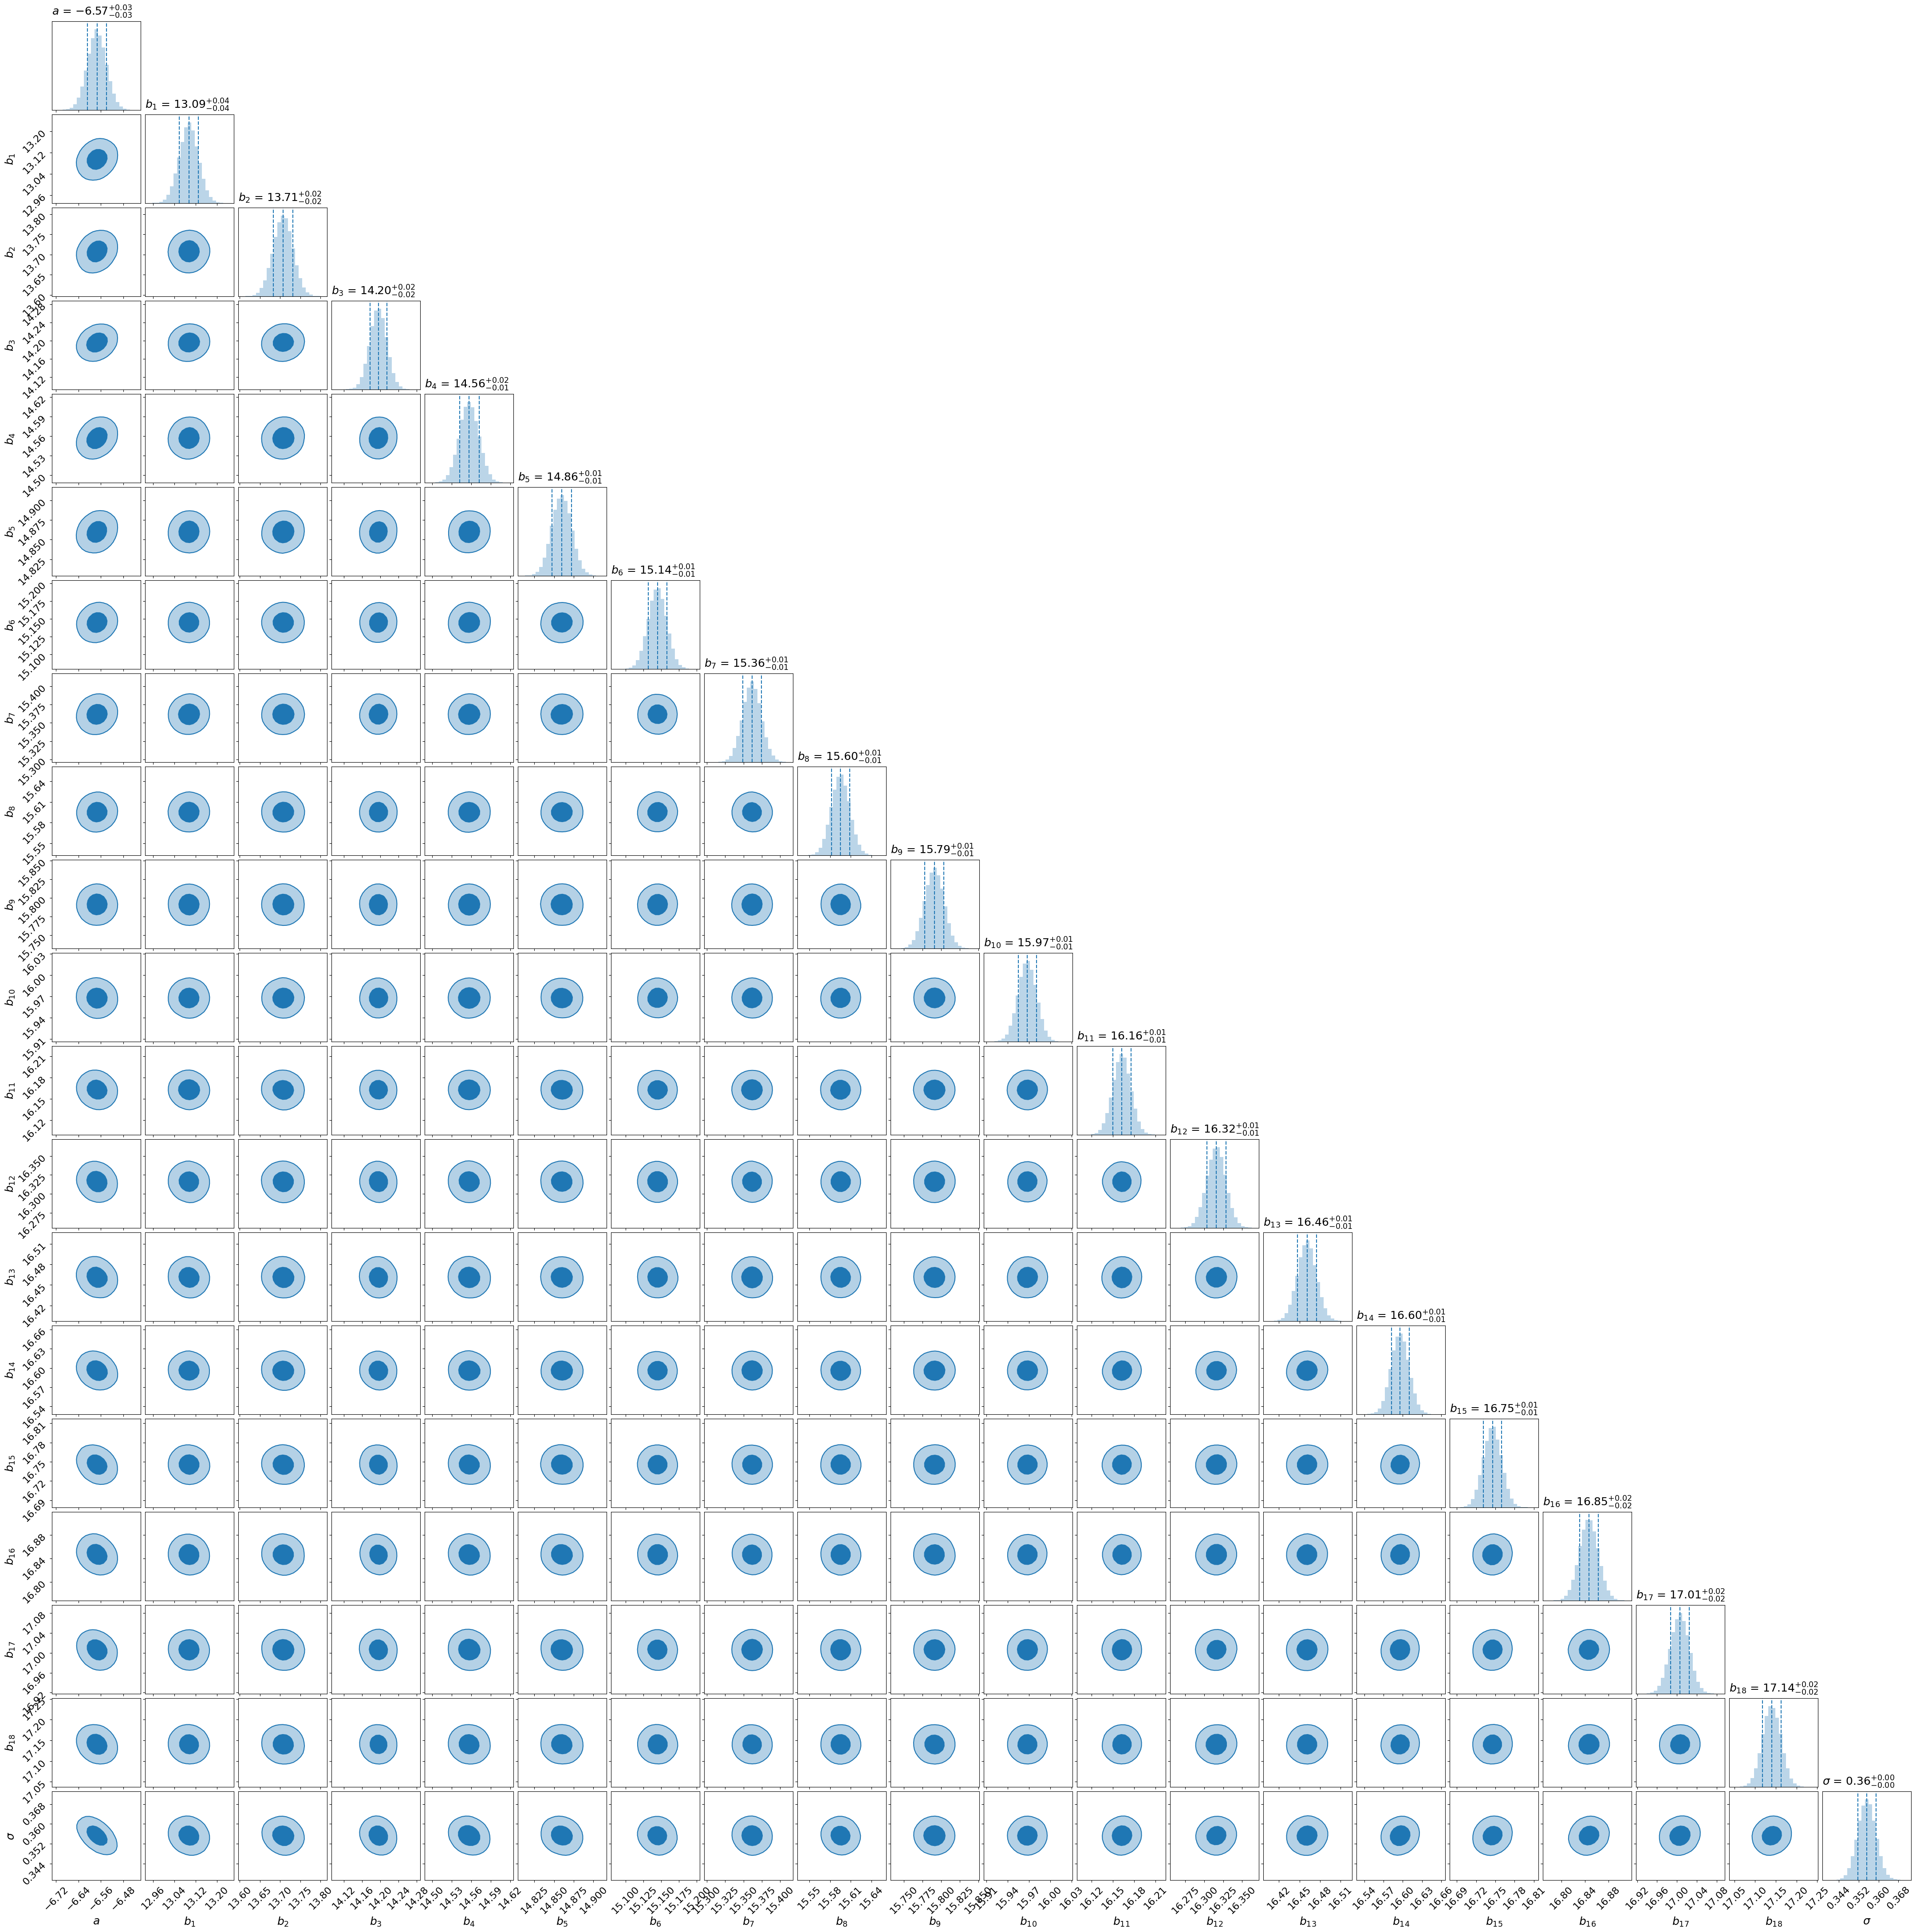

In [50]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$'] #+ [rf'$\sigma_{k}$' for k in np.arange(m)]

fig = corner(tfr_mcmc_samples.T, bins=25, smooth=1,
#              range=[[1.9, 2.4], [0.75, 1.1], [0.1, 0.3]],   # Range for a, b, sigma. Adjust as needed.
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_cornerplot_v3.png',
#     dpi=150,
#     bbox_inches='tight',
#     pad_inches=0.2,
#     facecolor='none'
# )

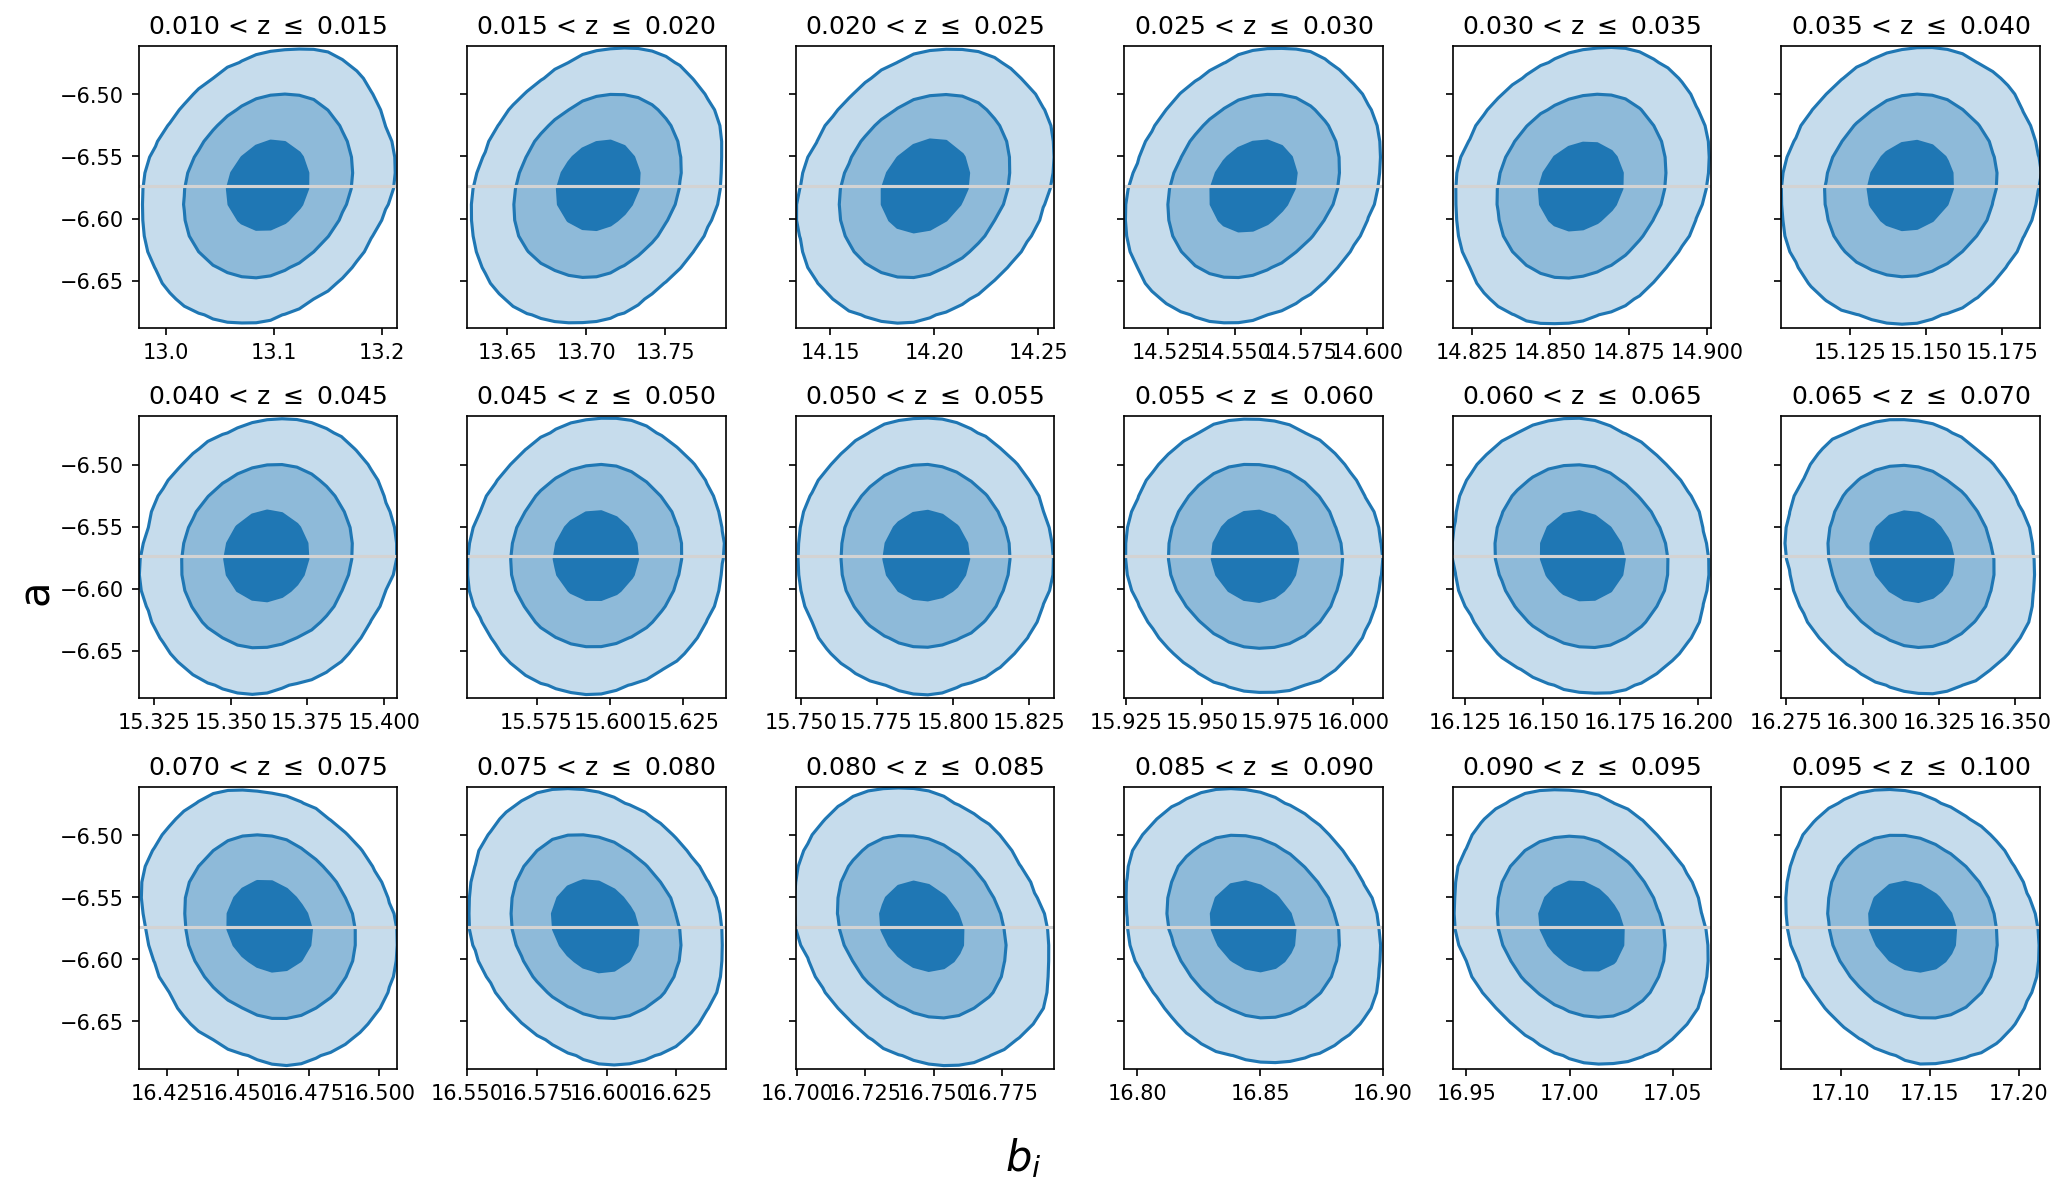

In [51]:
samples = tfr_mcmc_samples.T
a = samples[:, 0]
b_vals = samples[:, 1:-1]
n_b = b_vals.shape[1]
ncols = 6
nrows = 3
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=False, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)

axs = np.array(axs).reshape(-1)

for i in range(n_b):
    ax = axs[i]

    hist2d(
        b_vals[:, i],
        a,
        ax=ax,
        bins=25,
        smooth=1,
        levels=(1-np.exp(-0.5), 1-np.exp(-2), 1-np.exp(-4.5)),
        plot_datapoints=False,
        fill_contours=True,
        color='tab:blue'
    )
    ax.axhline(np.median(a), color='lightgray')

    ax.set(
        xlim = np.percentile(b_vals[:, i], [0.05,99.95]),
        ylim = np.percentile(a, [0.05,99.95]),
        title=f'{zbins[i]:.3f} < z $\\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
    )

    # if i % ncols == 0:
    #     ax.set_ylabel(f'$b_{{{i+1}}}$', fontsize=14)
    # if i >= (nrows-1)*ncols:
    #     ax.set_xlabel('$a$', fontsize=14)


# turn off unused axes
for j in range(n_b, len(axs)):
    axs[j].axis('off')

fig.supxlabel(r'$b_i$', fontsize=20)
fig.supylabel('a', fontsize=20)

plt.tight_layout()
# plt.show()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v2_fit_contours.png', 
#             dpi=150, 
#             facecolor='none')


### Plot the HyperFit Results

In [52]:
sigma_mcmc = np.percentile(tfr_mcmc_samples[-1], [16., 50., 84.])
a_mcmc = np.percentile(tfr_mcmc_samples[0], [16., 50., 84])
b_mcmc = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc.append(np.percentile(tfr_mcmc_samples[k], [16., 50., 84.]))
b_mcmc = np.asarray(b_mcmc)

In [53]:
i=0
while i < 20:
    print(f'{np.mean(tfr_mcmc_samples[i]):.4f}, {np.sqrt(cov_tfr[i,i]):.4f}')
    i+=1

-6.5736, 0.0341
13.0947, 0.0361
13.7074, 0.0247
14.1956, 0.0187
14.5571, 0.0149
14.8598, 0.0125
15.1448, 0.0131
15.3618, 0.0128
15.5953, 0.0134
15.7910, 0.0130
15.9677, 0.0131
16.1625, 0.0128
16.3159, 0.0127
16.4611, 0.0139
16.5960, 0.0140
16.7457, 0.0142
16.8470, 0.0162
17.0058, 0.0190
17.1404, 0.0221
0.3553, 0.0036


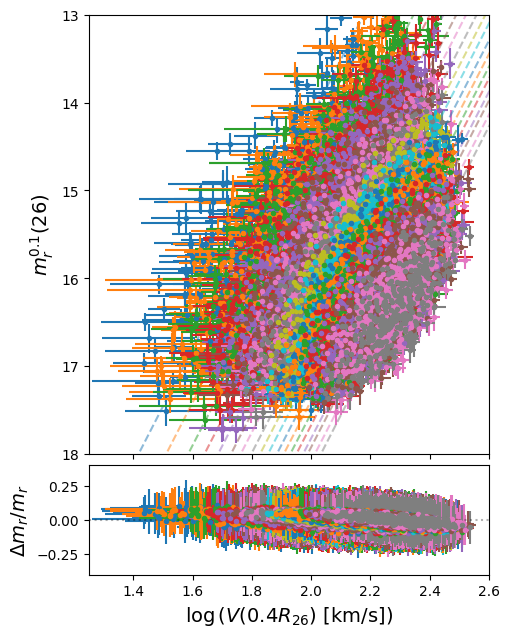

In [54]:
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[18, 13])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [55]:
print(f'slope (alpha): {-a_/2.5:.2f} +/- {np.sqrt(cov_tfr[0,0])/2.5:.3f}')

slope (alpha): 2.63 +/- 0.014


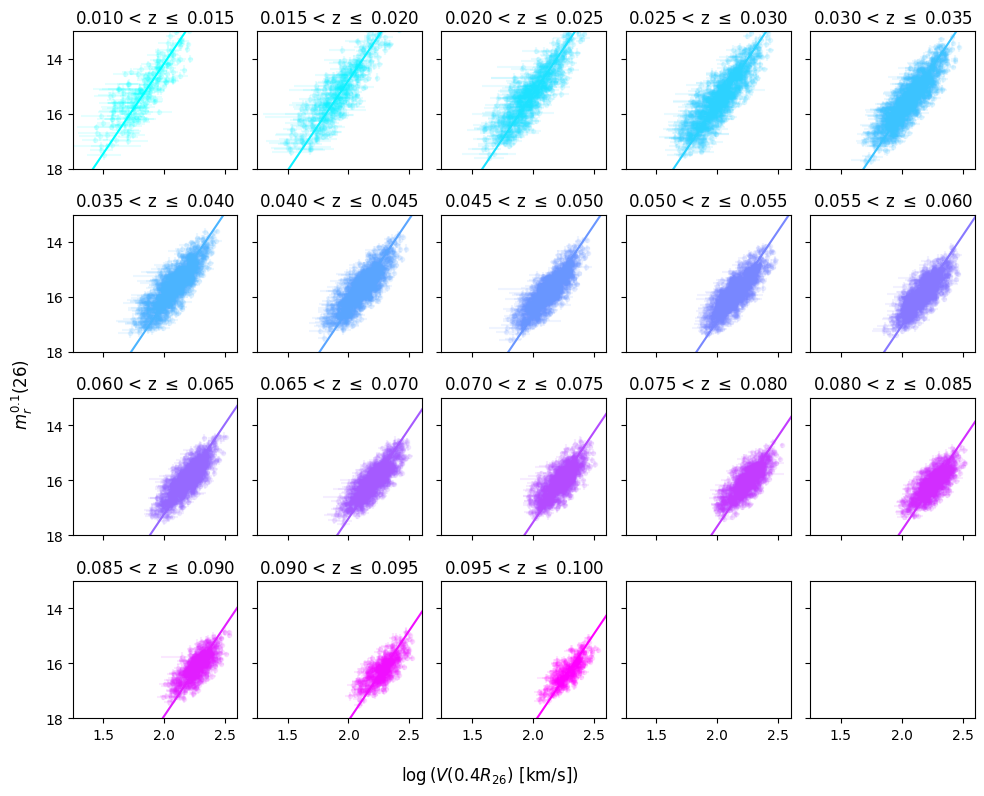

In [56]:
# fig, axs = plt.subplots(nrows=7, ncols=10, sharex=True, sharey=True, figsize=(20,16), tight_layout=True)
fig, axs = plt.subplots(nrows=4, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/5)
    col = i%5
    
    eb = axs[row,col].errorbar(logV0 + logV[i],#+1], 
                               mag[i],#+1], 
                               xerr=logV_err[i],#+1], 
                               yerr=mag_err[i],#+1], 
                               fmt='.', color=c, alpha=0.1)
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    
    axs[row,col].set(xlim=[1.25, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

# plt.savefig('../../Figures/Y1/TF_Y1_individual_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

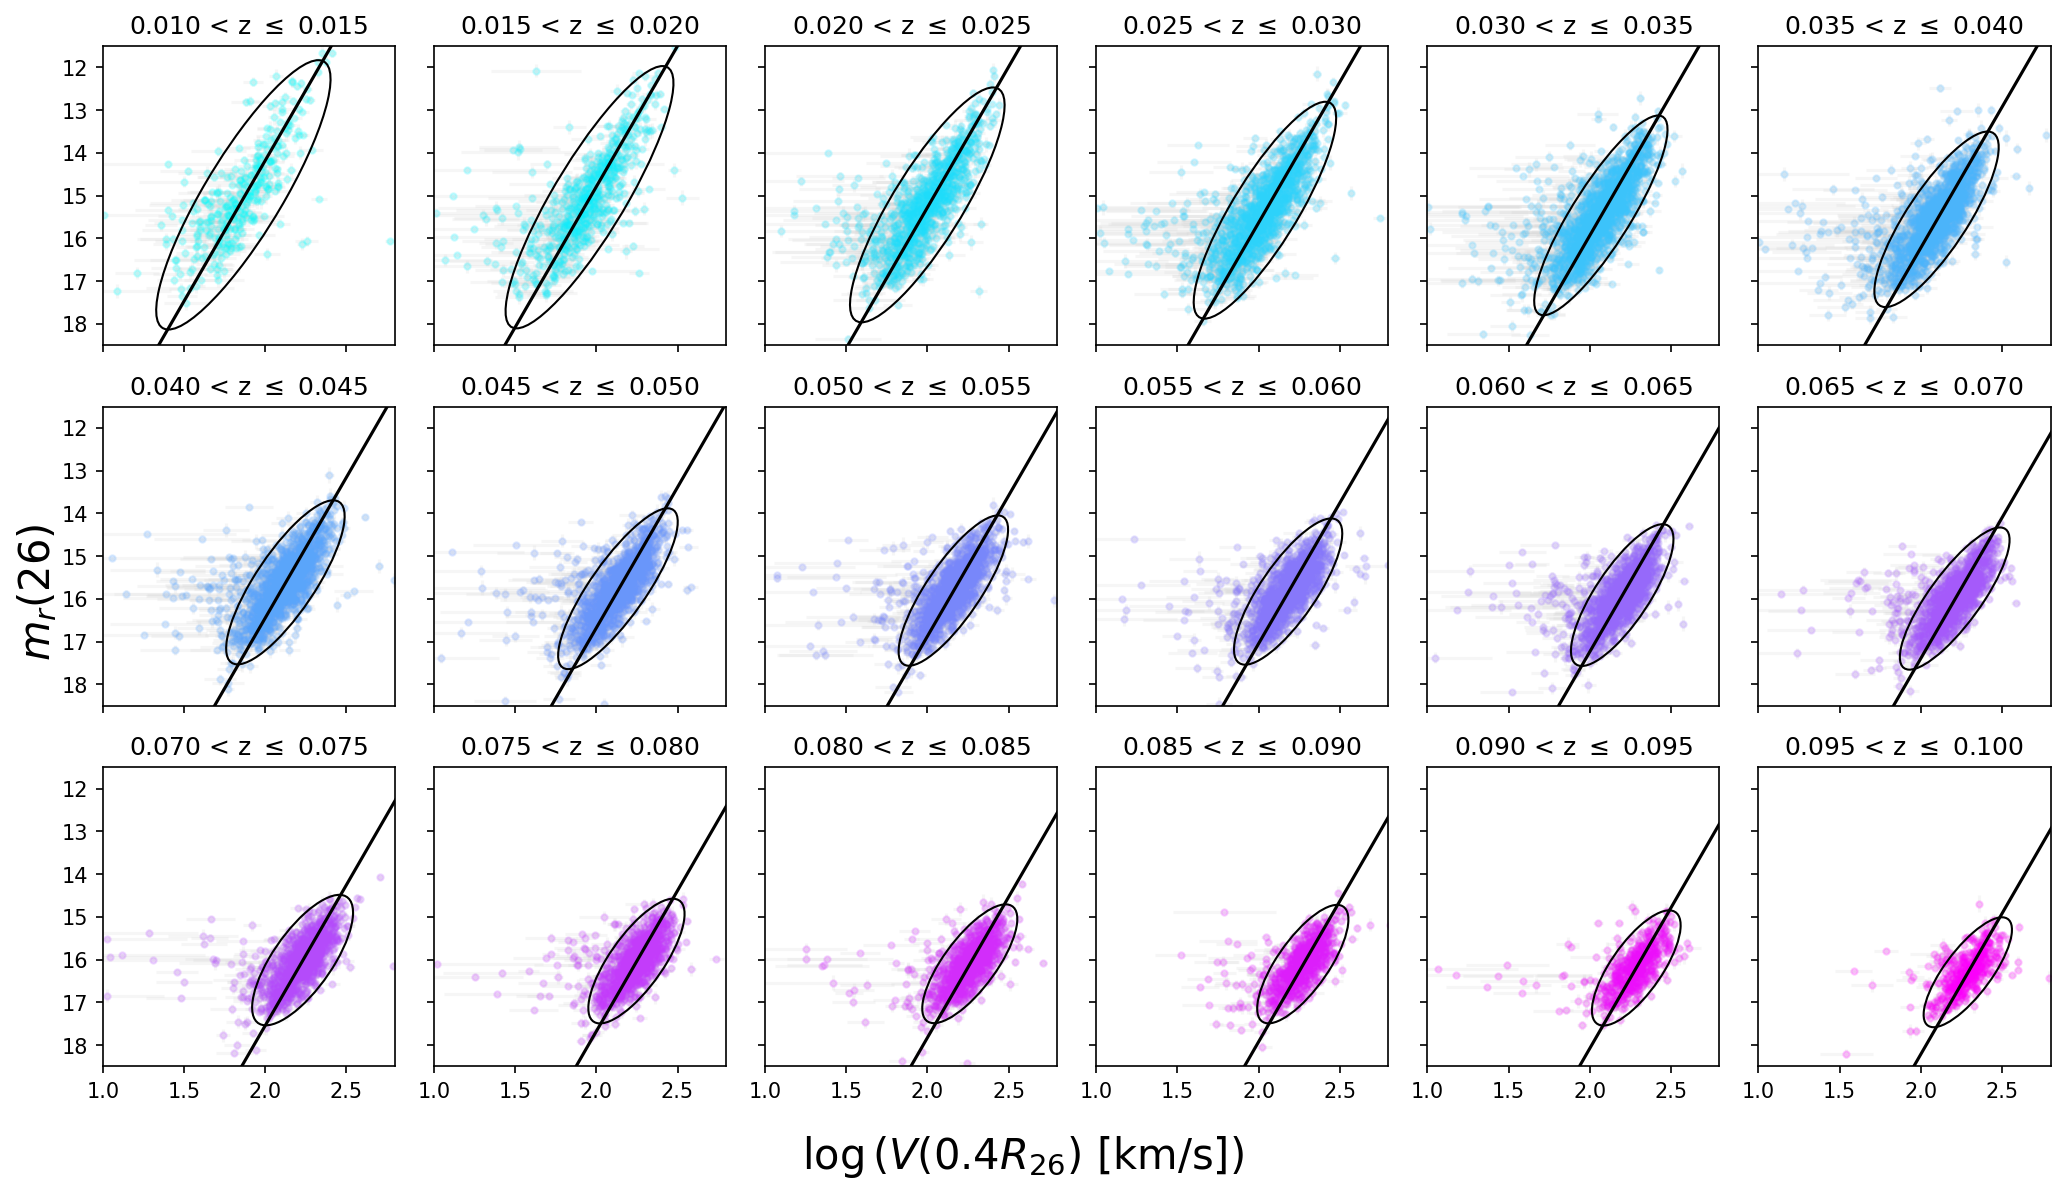

In [57]:
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
#             dpi=150, 
#             facecolor='none')


In [58]:
for i in range(m):

    # Number of galaxies in this bin
    N_gal = len(mag[i])

    # Calculate expected magnitude given the measured V
    mag_TF = a_*logV[i] + b_[i]

    # Calculate difference between the predicted and measured magnitude
    mag_diff = mag[i] - mag_TF

    # plt.figure(tight_layout=True)
    # plt.hist(mag_diff, bins=30)
    # break

    # Calculate rms
    rms_scatter = np.sqrt(np.sum(mag_diff**2)/N_gal)
    
    print(f'{i:2d}  {zbins[i]:0.3f} < z <= {zbins[i+1]:0.3f}, {N_gal}  {rms_scatter:.2f} mag')

 0  0.010 < z <= 0.015, 234  0.64 mag
 1  0.015 < z <= 0.020, 446  0.59 mag
 2  0.020 < z <= 0.025, 741  0.55 mag
 3  0.025 < z <= 0.030, 1092  0.53 mag
 4  0.030 < z <= 0.035, 1378  0.47 mag
 5  0.035 < z <= 0.040, 1247  0.48 mag
 6  0.040 < z <= 0.045, 1238  0.47 mag
 7  0.045 < z <= 0.050, 1116  0.45 mag
 8  0.050 < z <= 0.055, 1153  0.44 mag
 9  0.055 < z <= 0.060, 1098  0.45 mag
10  0.060 < z <= 0.065, 1148  0.43 mag
11  0.065 < z <= 0.070, 1111  0.43 mag
12  0.070 < z <= 0.075, 973  0.47 mag
13  0.075 < z <= 0.080, 919  0.43 mag
14  0.080 < z <= 0.085, 922  0.44 mag
15  0.085 < z <= 0.090, 690  0.42 mag
16  0.090 < z <= 0.095, 502  0.43 mag
17  0.095 < z <= 0.100, 375  0.38 mag


# Calculate logdistance ratios

In [59]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [60]:
rng = np.random.default_rng()

N_samples = 1000

mu_err = np.empty(len(sgatab['MU_ZCMB']))*u.mag

for i in tqdm(range(len(mu_err))):
    
    z_desi_random = rng.normal(np.abs(sgatab['Z_DESI_CMB'][i]), 
                               sgatab['ZERR_DESI'][i], 
                               N_samples)
    
    mu_random = cosmo.distmod(z_desi_random)
    
    mu_err[i] = np.std(mu_random)

sgatab['MU_ZCMB_ERR'] = mu_err

sgatab['R_ABSMAG_SB26_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['MU_ZCMB_ERR'].value**2)

100%|██████████| 23995/23995 [00:23<00:00, 1028.89it/s]


In [61]:
# Center redshift values of each bin
zmin = 0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [62]:
slopes = tfr_mcmc_samples[0]
slope = np.median(tfr_mcmc_samples[0])
slope_err = np.sqrt(cov_tfr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_mcmc_samples[1:-1] - mu_zc[:,None].value
ZP = np.median(tfr_mcmc_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_tfr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_mcmc_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

In [63]:
spiral_boolean = sgatab['MORPHTYPE_AI'] == 'Spiral'
irregular_boolean = sgatab['MORPHTYPE_AI'] == 'Irregular'
# other_boolean = sgatab['MORPHTYPE_AI'] == 'Other'

VI_boolean = sgatab['JOHN_VI'].mask

morph_boolean = (spiral_boolean | irregular_boolean) & VI_boolean

In [64]:
sgatab['GOOD_MORPH'] = morph_boolean

print(sum(outlier_boolean), 'outliers')
print(sum(~outlier_boolean), 'non-outliers')
print('-----------')
print(np.sum(morph_boolean), 'spirals & irregulars that pass VI')
print(np.sum(morph_boolean & outlier_boolean), 'outliers')
print(np.sum(morph_boolean & ~outlier_boolean), 'non-outliers')

1953 outliers
22042 non-outliers
-----------
23422 spirals & irregulars that pass VI
1766 outliers
21656 non-outliers


In [79]:
# Create a single column to denote which objects should be used for cosmological analysis
sgatab['OUTLIER'] = outlier_boolean
sgatab['MAIN'] = ~sgatab['OUTLIER'] & sgatab['GOOD_MORPH']

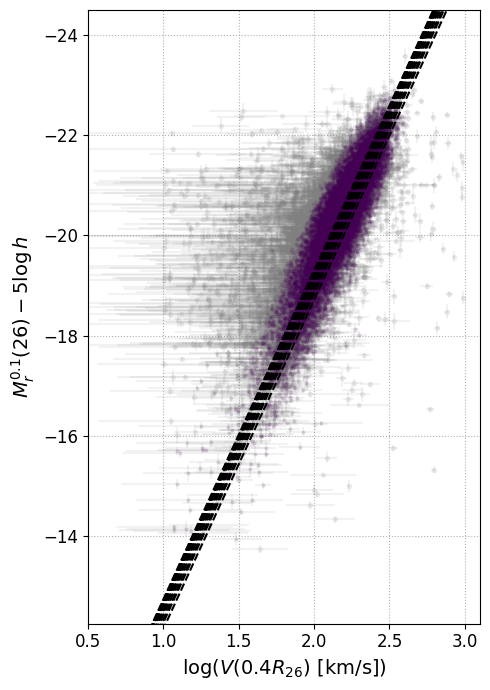

In [65]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = outlier_boolean# & morph_boolean
plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean# & morph_boolean
plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.1, 
             ecolor='gray')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
#              sgatab['R_ABSMAG_SB26'][sample], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')



plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

Text(0, 0.5, '$M_r(26)$')

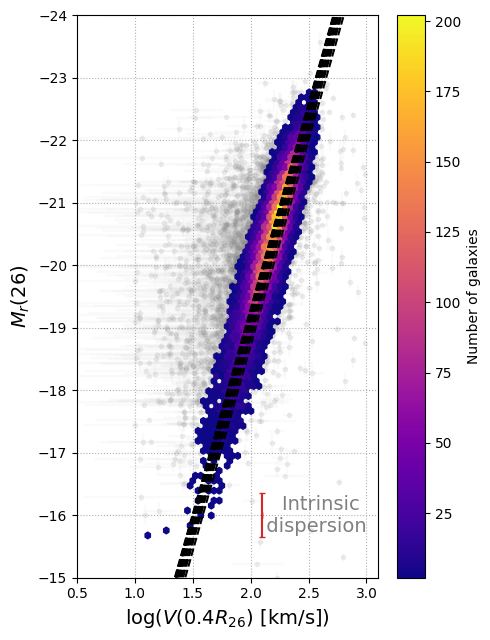

In [66]:
plt.figure(figsize=(5,6.5), tight_layout=True)
plt.grid(ls=':')

plt.errorbar(np.log10(sgatab['V_0p4R26'][outlier_boolean]), 
             sgatab['R_ABSMAG_SB26'][outlier_boolean], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][outlier_boolean]/sgatab['V_0p4R26'][outlier_boolean],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][outlier_boolean], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='lightgray', zorder=1)

plt.hexbin(np.log10(sgatab['V_0p4R26'][~outlier_boolean]), 
           sgatab['R_ABSMAG_SB26'][~outlier_boolean], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)


plt.errorbar([2.1], [-16], 
             xerr=0,
             yerr=sig, 
             ecolor='tab:red', 
             capsize=2)
plt.annotate('Intrinsic \n dispersion', 
             (3, -16), 
             va='center',
             ha='right',
             c='gray',
             fontsize=14)

plt.xlim([0.5, 3.1])
plt.ylim([-15, -24])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_tfr_hexbin_hyperfit_v3b.png', 
#             dpi=150, 
#             facecolor='none')

#### Redshift distribution

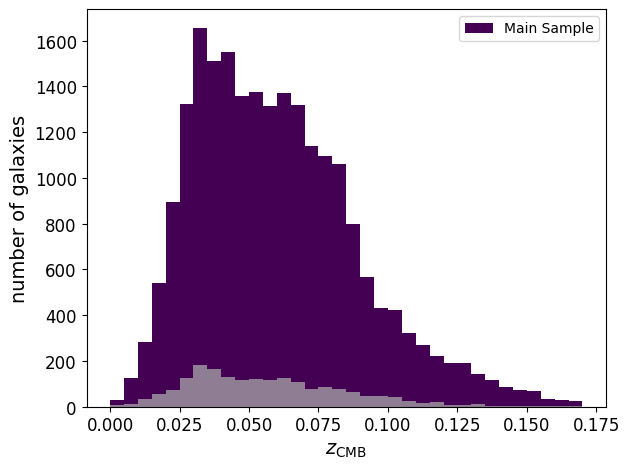

In [67]:
plt.figure(tight_layout=True)

plt.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), label='Main Sample')
plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), 
         color='darkgray',
         alpha=0.75, label='')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14)
plt.legend()
# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_histogram_z.png', 
#             dpi=150, 
#             facecolor='none')

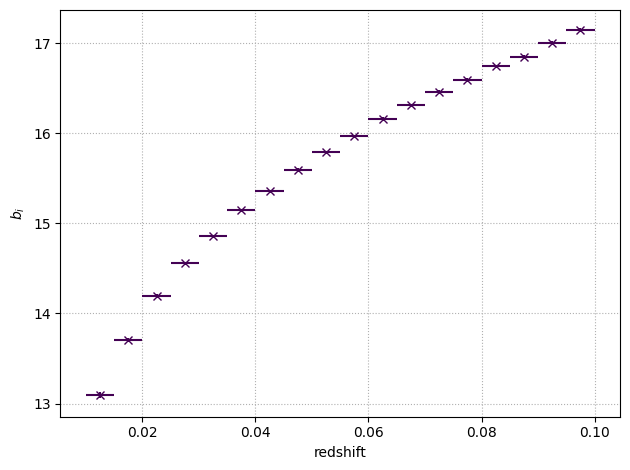

In [68]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_mcmc_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

# plt.xlim(0.028, 0.102)
# plt.ylim(-20.5, -20.7)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Distance moduli

In [69]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
sgatab['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(sgatab)):
    sgatab['R_ABSMAG_SB26_TF'][i] = slope*(np.log10(sgatab['V_0p4R26'][i]) - logV0) + ZP[zbin_indices[i] - 1]

In [70]:
sgatab['R_ABSMAG_SB26_TF_ERR'] = np.nan
sgatab['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(sgatab))):
    
    v_random = rng.normal(sgatab['V_0p4R26'][i], 
                          sgatab['V_0p4R26_ERR'][i], 
                          # size=10000)
                          size=len(slopes))
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random_good) - logV0) + ZP[zbin_indices[i] - 1]

    sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[zbin_indices[i] - 1,v_random > 0]
    
    sgatab['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(np.nanstd(Ms)**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
sgatab['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(sgatab['R_ABSMAG_SB26_TF_ERR']**2 - sgatab['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 23995/23995 [36:58<00:00, 10.81it/s]


In [71]:
def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

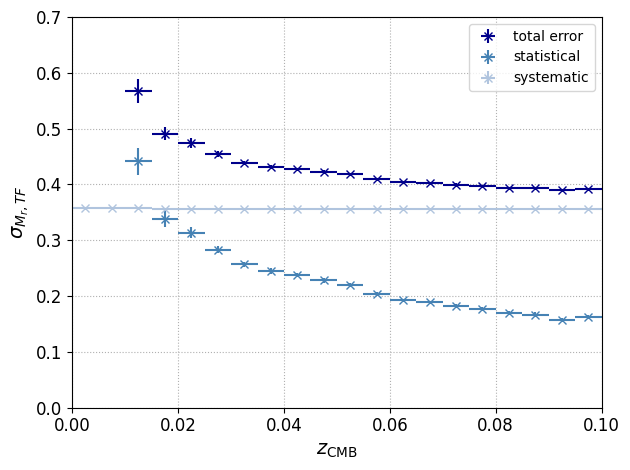

In [72]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

plt.figure(tight_layout=True)

# plt.plot(tf_data['Z_DESI_CMB'][sample1], tf_data['R_ABSMAG_SB26_TF_ERR'][sample1], '.', alpha=0.1)

# Total uncertainty
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='total error')

# Statistical uncertainty (just from velocity uncertainty)
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='steelblue', label='statistical')

# Systematic uncertainty (from TF calibration)
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR_SYS'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='systematic')

plt.grid(ls=':')

plt.legend()

plt.xlim(0, 0.1)
plt.ylim(0, 0.7)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\sigma_{M_r, TF}$', fontsize=14);

## Compute distance modulus based on our TFR

In [73]:
sgatab['MU_TF'] = sgatab['R_MAG_SB26_CORR'] - sgatab['R_ABSMAG_SB26_TF']

sgatab['MU_TF_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['R_ABSMAG_SB26_TF_ERR']**2)

## $\Delta M_r$ v. redshift

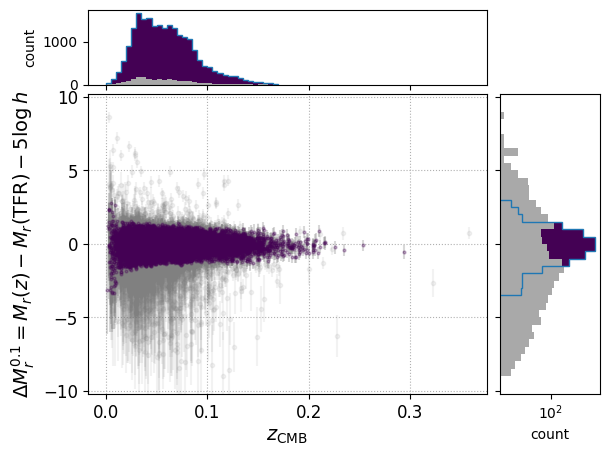

In [74]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

sample = outlier_boolean# & morph_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M_r^{0.1} = M_r(z) - M_r(\text{TFR}) - 5\log h$', fontsize=14)

ax.set_ylim((-10.2, 10.2))


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
sample1 = ~outlier_boolean
sample2 = outlier_boolean
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample2] - sgatab['R_ABSMAG_SB26_TF'][sample2], 
              bins=np.arange(-12.5, 10, 0.5), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal', 
              histtype='step', 
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

## $\eta$ v. redshift

In [75]:
sgatab['LOGDIST'] = 0.2*(sgatab['MU_ZCMB'] - sgatab['MU_TF'])
sgatab['LOGDIST_ERR'] = 0.2*np.sqrt(sgatab['MU_ZCMB_ERR']**2 + sgatab['MU_TF_ERR']**2)

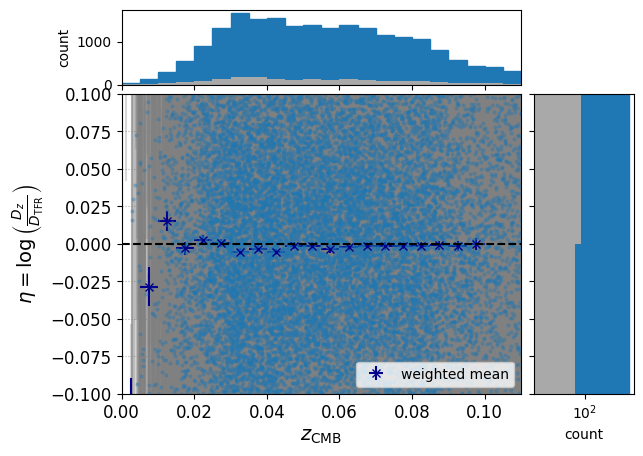

In [76]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

ax.errorbar(sgatab['Z_DESI_CMB'][sample2], 
             sgatab['LOGDIST'][sample2], 
             xerr=sgatab['ZERR_DESI'][sample2], 
             yerr=sgatab['LOGDIST_ERR'][sample2],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

ax.errorbar(sgatab['Z_DESI_CMB'][sample1], 
             sgatab['LOGDIST'][sample1], 
             xerr=sgatab['ZERR_DESI'][sample1], 
             yerr=sgatab['LOGDIST_ERR'][sample1],
             fmt='.', 
             markersize=4, 
             alpha=0.3,
             color='tab:blue',
             ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_LOGDIST'][sample1], 
                                    zbins, 
                                    median=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')
'''
# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.legend()

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1.9, 1.9))
ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.5, 0.5))
ax.set_ylim((-0.1, 0.1))
ax.set_xlim((0, 0.11))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              color='tab:blue',
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][sample2], 
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1),
              color='tab:blue',
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.1), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

# plt.savefig('../../Figures/Y1/iron_logdist-v-z_jointTFR-varyV0-perpdwarfs_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none', 
#             bbox_inches='tight');

/tmp/ipykernel_1609077/3551860298.py:35: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


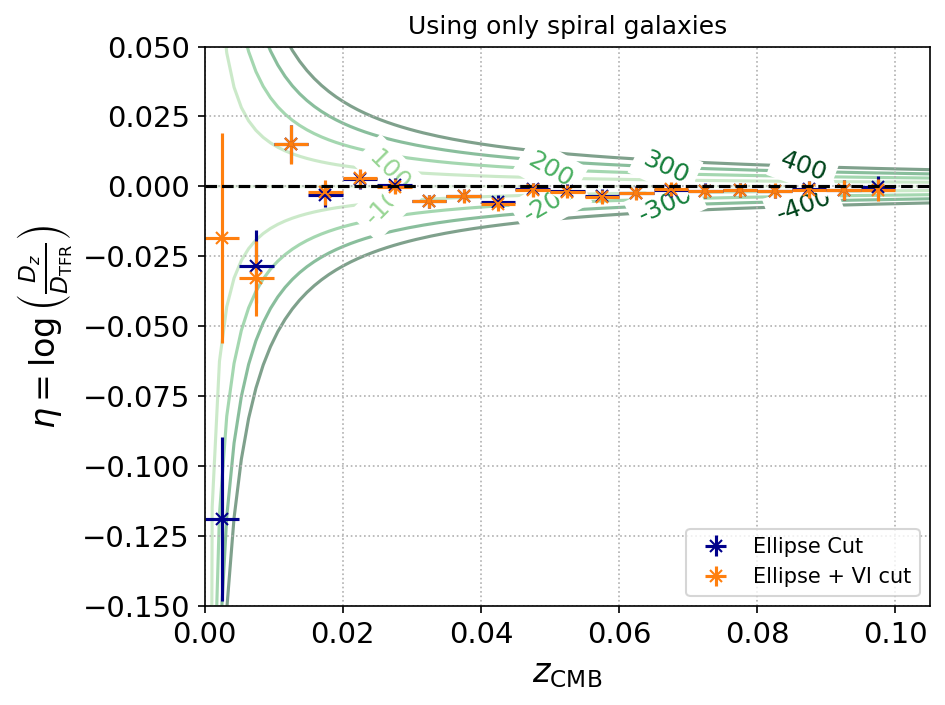

In [84]:
plt.figure(tight_layout=True, dpi=150, facecolor='none')

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Ellipse Cut')

sample1=sgatab['MAIN']
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='tab:orange', label='Ellipse + VI cut')




# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.15, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))
plt.title('Using only spiral galaxies')
plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_v3_eta_z.png',facecolor='none', dpi=150)

/tmp/ipykernel_1609077/4113657625.py:26: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.105)

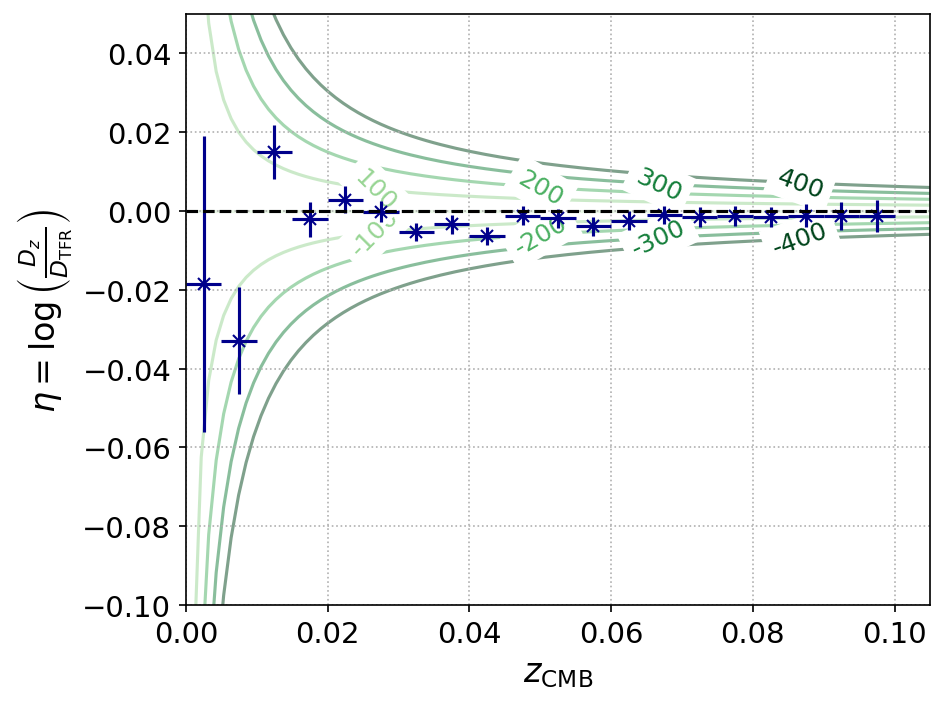

In [83]:
plt.figure(tight_layout=True, dpi=150, facecolor='none')

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=sgatab['MAIN']
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Main sample')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.1, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_v3_eta_z.png',facecolor='none', dpi=150)

In [ ]:
np.sum(sgatab['MAIN'])

In [85]:
hdr = fits.Header()

hdr['DESI_DR'] = 'DR1'
hdr['V_RADIUS'] = '0.4 R26'
hdr['M'] = slope
hdr['M_ERR'] = slope_err
# hdr['0PT'] = ZP
# hdr['0PT_ERR'] = ZP_err
hdr['logV0'] = logV0
hdr['SIG'] = np.median(tfr_mcmc_samples[-1])
hdr['SIG_ERR'] = np.sqrt(cov_tfr[-1,-1])
hdr['H0'] = H0
hdr['EL_STD'] = sigma
hdr['EL_TYPE'] = 'binned'


# hdr['EL_MU_X'] = ellipse_mean[0]
# hdr['EL_MU_Y'] = ellipse_mean[1]

# # Ellipse covariance matrix
# hdr['EL_COV00'] = ellipse_cov[0, 0]
# hdr['EL_COV01'] = ellipse_cov[0, 1]
# hdr['EL_COV10'] = ellipse_cov[1, 0]
# hdr['EL_COV11'] = ellipse_cov[1, 1]


empty_primary = fits.PrimaryHDU(header=hdr)

In [92]:
sgatab['MAIN'] = sgatab['MAIN'].filled(False)
sgatab['GOOD_MORPH'] = sgatab['GOOD_MORPH'].filled(False)

In [94]:
table_hdu = fits.BinTableHDU(data=sgatab)

hdul = fits.HDUList([empty_primary, table_hdu])

# Write results to file
hdul.writeto('../eta_cats/SGA_loa_jointTFR_v5_unweighted_spiralonly.fits', 
             overwrite=True)

In [90]:
sgatab_test = Table.read('../eta_cats/SGA_jura_jointTFR_v5_unweighted_spiralonly.fits')

(21656, 21656)

In [76]:
# hdul.writeto('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v3.fits', 
#              overwrite=True)

# Compare to other catalogs

In [ ]:
sgatab_old = Table.read('../eta_cats/SGA_jura_jointTFR_v3_unweighted.fits') # catalog with similar calibration, applied to spirals + irregulars

In [ ]:
plt.figure(tight_layout=True, dpi=150)

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=sgatab['MAIN']
sample2=sgatab_old['MAIN']
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Spirals Only')

N, y_avg, y_std = profile_histogram(sgatab_old['Z_DESI_CMB'][sample2], 
                                    sgatab_old['LOGDIST'][sample2], 
                                    zbins, 
                                    weights=sgatab_old['LOGDIST_ERR'][sample2]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='tab:orange', label='Spirals and Irregulars')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.1, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_v3_eta_z.png',facecolor='none', dpi=150)